# Benchmarking Dask in Rust



This work focuses on converting code in dask from Python to Rust with the aim of reducing the time it takes to run the code. This Juypter notebook shows the speedup that certain functions are having being written in rust.

Rust is a programming language that is proven to be faster than Python, especially for CPU bound operations and processing large amounts of data.

This notebook compares the execution time of several function in two forms.
One the original python version
Two the modified function where some or all of the code has been moved to Rust

It tests how long it runs in Python and in Rust using different sized inputs. Each input size has multiple tests and the average of all the tests is taken to minimise the impact of any outliers. The x axis shows the size of the input and the y axis shows the average time taken of each input of size x.

This notebook will show which functions benefitted being moved into Rust.



# Filtering a dataframe



Both create a random dataframe of x rows and 5 columns and then the time reported is the time it takes to filter out the first column by values that are one



In [1]:
import time

import dask.array as da
import dask.dataframe as dd

import tiatoolbox.rust.dask as rdask


def py_filter_dask(x: int) -> float:
    """Measure the execution time of a Dask DataFrame filtering operation."""
    arr = da.random.randint(0, 2, size=(x, 5), chunks=(100_000, 5))
    df = dd.from_dask_array(arr, columns=["col1", "col2", "col3", "col4", "col5"])
    start_time = time.time()
    filtered_df = df[df["col1"] == 1]
    filtered_df.compute()
    return time.time() - start_time

In [2]:
import numpy as np

sizeofarray = []
timings = []
i = 10
maxarraysize = 10000000
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        python_end_time = py_filter_dask(i)
        python_times = np.append(python_times, python_end_time)
        rust_end_time = rdask.filter_df(i)
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(i)
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

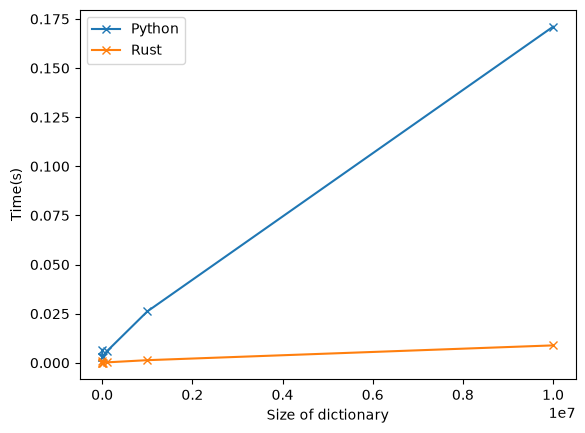

In [3]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings, marker="x")
plt.xlabel("Size of dictionary")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()

# Filtering a dataframe



Both create a random dataframe of x rows and 5 columns and then the time reported is the time it takes to filter out the first column by values that are one



In [4]:
import tiatoolbox.rust.dask as rdask


def py_filter_dask(df: dd.DataFrame) -> None:
    """Filter a Dask DataFrame and compute the resulting rows."""
    filtered_df = df[df["col1"] == 1]
    filtered_df.compute()

In [5]:
import pandas as pd


def rust_wrapper(partition: pd.DataFrame) -> pd.DataFrame:
    """Filter a pandas DataFrame partition using the Rust implementation."""
    values = partition.to_numpy()
    result = rdask.filter_df_given_df(values, 1)
    return pd.DataFrame(result, columns=partition.columns)

In [6]:
import numpy as np

sizeofarray = []
timings = []
i = 10
maxarraysize = 10000000
while i <= maxarraysize:
    python_times = np.empty(0)
    rust_times = np.empty(0)
    for _j in range(10):
        arr = da.random.randint(0, 2, size=(i, 5), chunks=(100_000, 5))
        df = dd.from_dask_array(arr, columns=["col1", "col2", "col3", "col4", "col5"])
        start_time = time.time()
        py_filter_dask(df)
        python_end_time = time.time() - start_time
        python_times = np.append(python_times, python_end_time)
        arr = da.random.randint(0, 2, size=(i, 5), chunks=(100_000, 5))
        df = dd.from_dask_array(arr, columns=["col1", "col2", "col3", "col4", "col5"])
        start_time = time.time()
        out = df.map_partitions(rust_wrapper, meta=df)
        out.compute()
        rust_end_time = time.time() - start_time
        rust_times = np.append(rust_times, rust_end_time)
    sizeofarray.append(i)
    timings.append([np.average(python_times), np.average(rust_times)])
    i *= 10

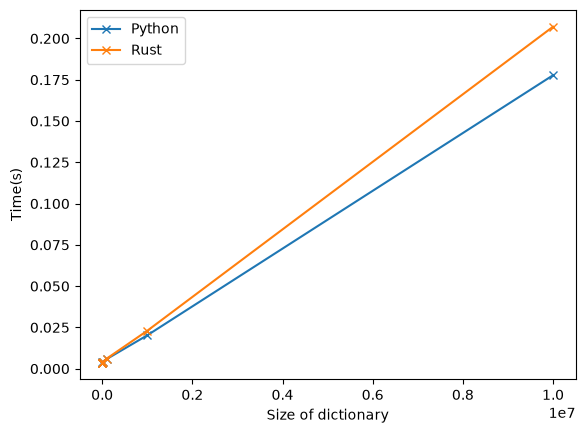

In [7]:
import matplotlib.pyplot as plt

plt.plot(sizeofarray, timings, marker="x")
plt.xlabel("Size of dictionary")
plt.ylabel("Time(s)")
plt.legend(["Python", "Rust"])
plt.show()